# Application of WAVEGUISE to an example of convective GWs observed by AWE
This script is to show in detail how WAVEGUISE is applied to a complex 2-D data set and how it retrieves wave packets.

In [1]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d_v3 as two
import plot_tools as pt
import utils_AWE as AWE

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib import cm
import time

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '../data/awe_l3c_q20_2024123T0557_02514_v01.nc'
ds = xr.open_dataset(data_path)

## Data Preprocessing
Before the observational data set is ready for the wavelet transform, we must take care of the data boundaries. These non-periodic boundaries can create strong frequency responses and later on fuck up the wavefield segmentation. The first step is to use a least square polynomial 2D fit of max_order and subtract the result. In a second step, the zeroth and first Fourier components are also subtracted. In a final step, a Tukey window is applied to smoothly enforce the signal to zero at the edges. 

In [4]:
orig = ds["Radiance"].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values)
dx, dy = 2000, 2000
nx, ny = orig['x_along_track'].size, orig['y_cross_track'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

print(f"Data size: {signal.shape[0]:.0f}x{signal.shape[1]:.0f}")

Domain size: 700 268
Data size: 268x700


## Wavelet Transform
When we do the juwavelet transform we need to choose the number of scales $js$ and orientations $jt$. The smallest scales is defined as $s_0=4*\delta x$. The number of scales is taken to depend on the data dimensions and since the first Fourier component is already subtracted, we focus here on wavelengths shorter than that. For more details on juwavelet, please have a look at Ungermann and Reichert (2025).

In [5]:
s0 = 4 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 21

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

params = {
    "Smallest scale (s0)": f"{s0:.0f}",
    "Largest scale (s1)": f"{s1:.0f}",
    "Scale sampling (dj)": f"{dj:.3f}",
    "Number of scales (js)": f"{js:.0f}",
    "Number of azimuth angles (jt)": f"{jt:.0f}",
    "Non-dimensional frequency": f"{cwt_result['opts']['param']:.2f}",
}
label_width = max(len(label) for label in params)
for label, value in params.items():
    print(f"{label:<{label_width}} : {value}")

/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 2 km and the smallest wavelength you analyze is 8 km.
The data domain is at least 536 km and the largest wavelength you analyze is 235 km.
Smallest scale (s0)           : 4
Largest scale (s1)            : 134
Scale sampling (dj)           : 0.125
Number of scales (js)         : 40
Number of azimuth angles (jt) : 21
Non-dimensional frequency     : 6.28


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


## Denoising
Before we continue with the segmentation, it is very useful to strip off any noise. I implemented two ways. 
1. The first approach creates a 2D white noise field - the standard deviation should be e.g. in the order of the expected instrument noise - and computes the wavelet amplitude spectrum $|W_{noise}|(s,\vartheta,x,y)$ of that. To get a robust measure of scale-dependent noise amplitudes, I compute the average resulting in $|\overline{W}_{noise}|(s)$. All wavelet coefficients for which $|W_{signal}|(s,\vartheta,x,y)<|\overline{W}_{noise}|(s)$ are set to zero.
2. The second approach reduces colored noise. To do so the wavelet amplitude spectrum is normalized according to $|W_{norm}|=\frac{|W_{signal}|-median(W_{signal})}{sMAD(W_{signal})}$. All wavelet coefficients for which $|W_{norm}|<3$ are set to zero.

In [6]:
# Denoising
noise_level = 0.8 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=noise_level,sMAD_threshold=3,mean_axis=(1,2,3))

Text(0.03, 0.94, 'c')

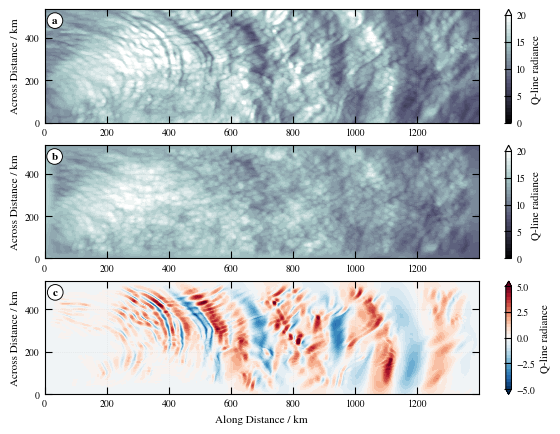

In [7]:
BI_lev = np.linspace(0,20,31)
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig,levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_orig,ticks=[0,5,10,15,20],label='Q-line radiance')

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low+signal-wavy_stuff+np.mean(orig.values),levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_dirt,ticks=[0,5,10,15,20],label='Q-line radiance')

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff,levels=np.linspace(-5,5,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave,ticks=[-5,-2.5,0,2.5,5],label='Q-line radiance')

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

## Segmentation
In the following step, we apply the watershed segmentation algorithm to the denoised WAS. A crucial parameter is the prominence, which defines the height of a peak in the WAS comapred to its neighborhood. A suggestion for the prominence parameter would be the noise level of the underlying data. Depending on the prominence parameter we will find more or less wave packets.

In [8]:
WAS        = np.abs(denoised_cwt['decomposition'])
start_time = time.time()
seg_v1     = two.wavefield_segmentation_2d(WAS,0.2,connectivity=1)
print("--- %s seconds ---" % (time.time() - start_time))
print('Identified', np.max(seg_v1), 'initial wave packets!')

--- 796.5000438690186 seconds ---
Identified 73 initial wave packets!


## Clustering
I want to stitch wave packets together that share scale and orientation. However, if they do not overlap in (x,y) I will keep them as separated wave packets.

In [9]:
k     = 2 * np.pi / cwt_result["period"]
theta = cwt_result["theta"]
eps   = np.abs(np.diff(np.log(k)))[0]*np.sqrt(2)
labels, cluster_labels = two.find_clusters_logk_theta(denoised_cwt, seg_v1, eps=eps)
cluster_map            = two.build_cluster_map_with_noise(labels,cluster_labels)
seg_v2                 = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Number of wave packets after Clustering', np.max(seg_v2))

suggested scaling: 0.579168450400712
Number of wave packets after Clustering 58


In [10]:
eps

np.float64(0.12253226793356874)

## Filtering
To consider only the most significant wave packets, I apply a variance filter that passes only as many wave packets until 99% of total variance are reconstructed.

In [8]:
seg_v3 = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.98)
print('Final number of wave packets:', np.max(seg_v3))

Final number of wave packets: 14


Text(0.5, 1.0, 'After Variance Filtering')

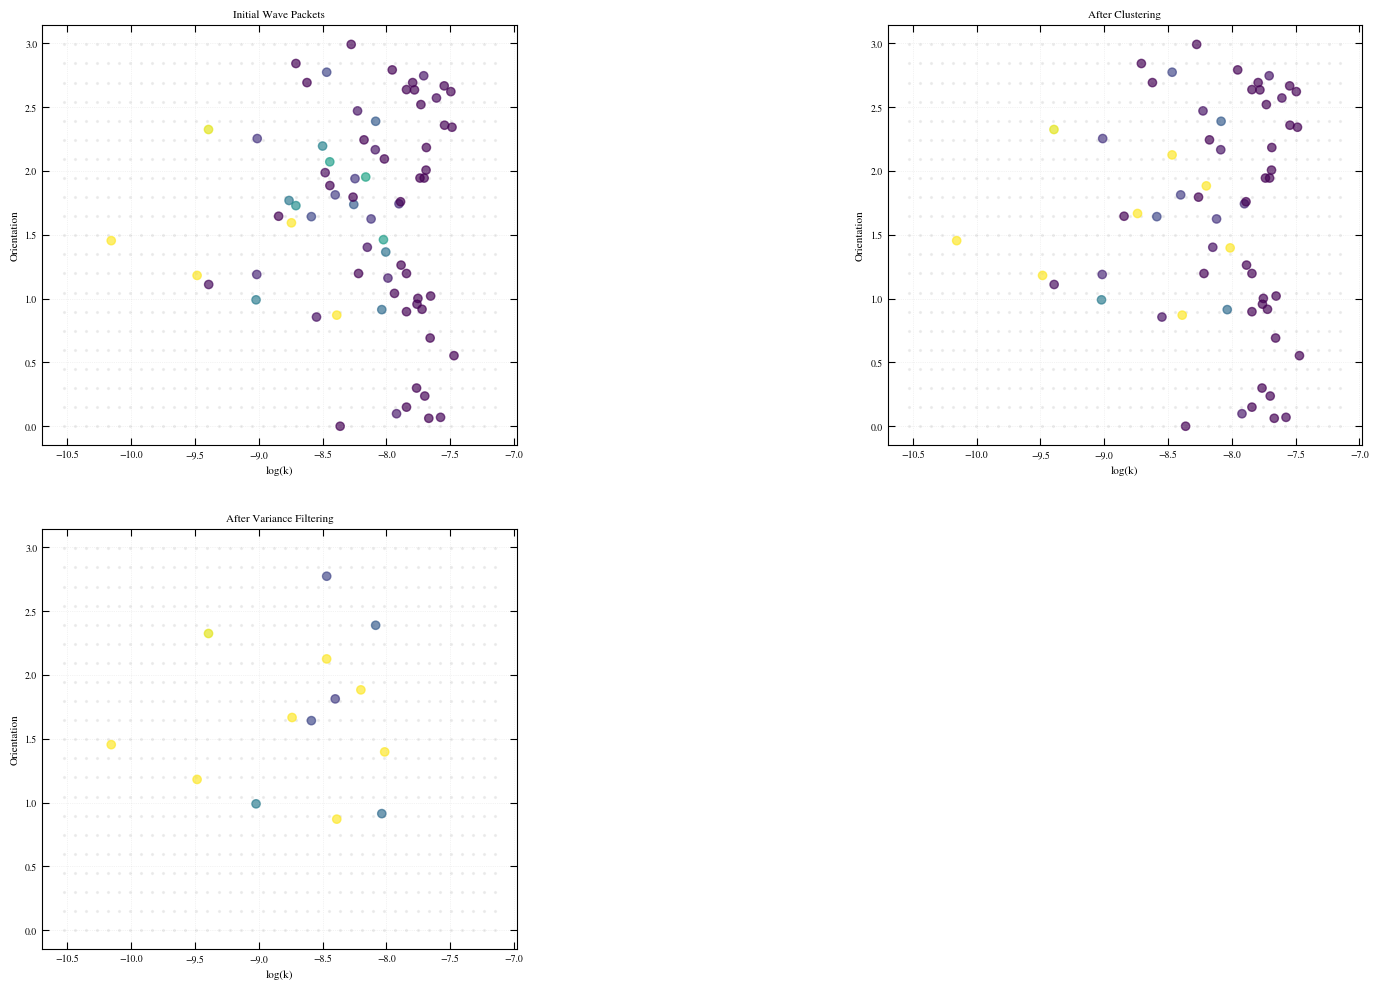

In [53]:
labels_1, amp_seg_1, kx_seg_1, ky_seg_1, k_seg_1, theta_seg_1 = two.segments2points_pi_periodic(WAS, k, theta, seg_v1)
labels_2, amp_seg_2, kx_seg_2, ky_seg_2, k_seg_2, theta_seg_2 = two.segments2points_pi_periodic(WAS, k, theta, seg_v2)
labels_3, amp_seg_3, kx_seg_3, ky_seg_3, k_seg_3, theta_seg_3 = two.segments2points_pi_periodic(WAS, k, theta, seg_v3)

scaling=1#0.58

fig = plt.figure(figsize=(15,10))
ax1=fig.add_subplot(221)
ax2=fig.add_subplot(222)
ax3=fig.add_subplot(223)

# Grid
for ia in k:
    for ib in theta:
        ax1.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)
        ax2.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)
        ax3.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)

vmax = np.percentile(amp_seg_1,95)

ax1.scatter(np.log(k_seg_1),scaling*theta_seg_1,c=amp_seg_1,alpha=0.67,vmin=0,vmax=vmax)
ax2.scatter(np.log(k_seg_2),scaling*theta_seg_2,c=amp_seg_2,alpha=0.67,vmin=0,vmax=vmax)
ax3.scatter(np.log(k_seg_3),scaling*theta_seg_3,c=amp_seg_3,alpha=0.67,vmin=0,vmax=vmax)

ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel('log(k)')
ax1.set_ylabel('Orientation')
ax1.set_title('Initial Wave Packets')

ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel('log(k)')
ax2.set_ylabel('Orientation')
ax2.set_title('After Clustering')

ax3.set_aspect("equal", adjustable="box")
ax3.set_xlabel('log(k)')
ax3.set_ylabel('Orientation')
ax3.set_title('After Variance Filtering')

## Reconstruction
Every wave packet is reconstructed separately.

In [9]:
recon_WP, amp_WP, k_across_WP, k_along_WP = two.recon_allWP_2d(denoised_cwt, seg_v3)

100%|██████████| 187600/187600 [00:03<00:00, 59093.63it/s]


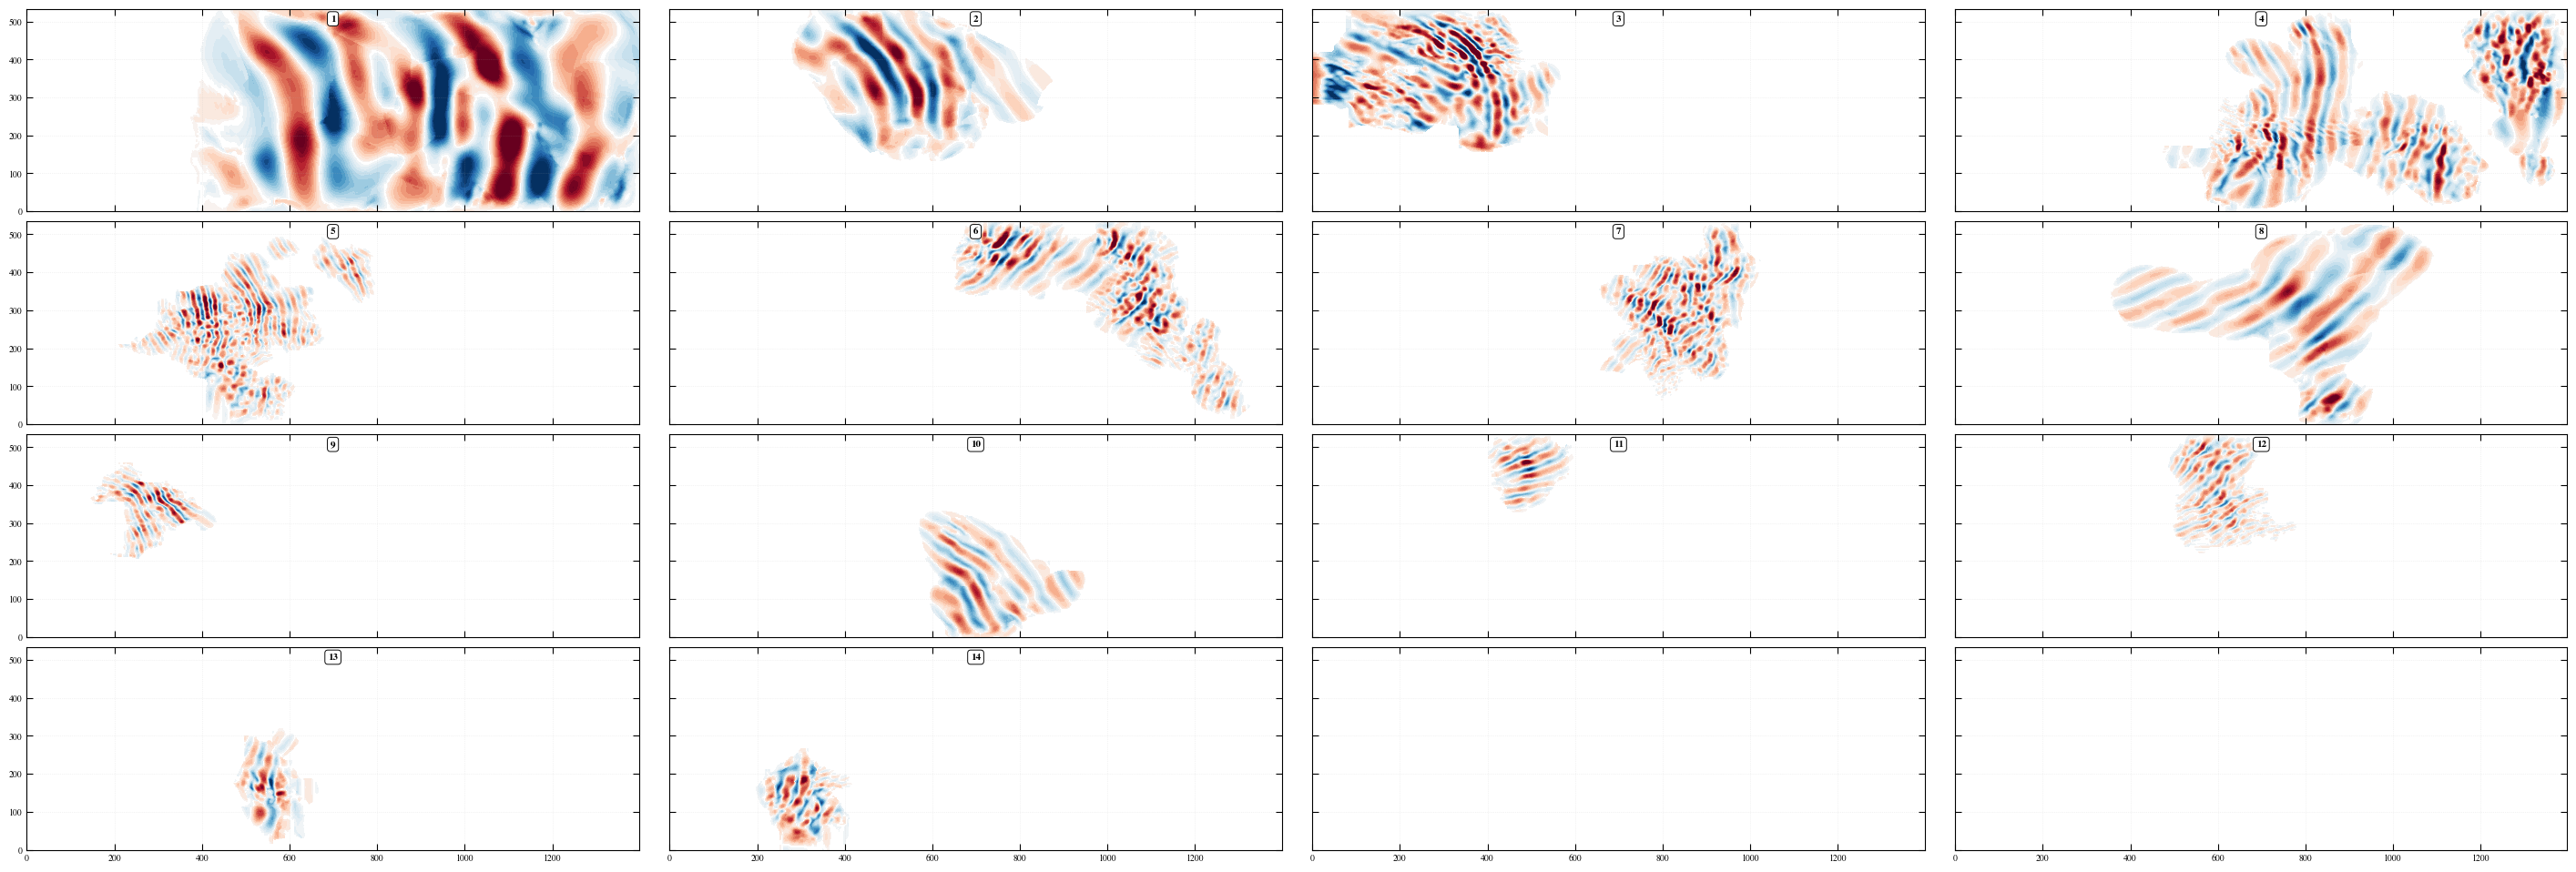

In [11]:
#Mit prominence=3 / sMAD_threshold=3 / eps=0.18 / dj = 1/8
rad_lev=np.linspace(-3,3,31)
row, col = pt.define_figgrid(recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            #ax[i][j].contourf(the_new_shit[i*col+j,:,:],levels=rad_lev,extend="both",cmap="RdBu_r")
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -0.1, 0.1)  
            norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
            ax[i,j].contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

## Wave packets of Interest

In [10]:
goliath = two.recon_WPoi_2d(denoised_cwt,seg_v3,[1,2,3,4,5,9,13,14])
david   = two.recon_WPoi_2d(denoised_cwt,seg_v3,[6,7,8,11,12])

100%|██████████| 187600/187600 [00:05<00:00, 35444.80it/s]


In [11]:
# Reconstruct the dominant waves only

dec = denoised_cwt['decomposition']
WAS = np.abs(dec)

# flatten (freq, wavenumber)
WAS_flat   = WAS.reshape(-1, WAS.shape[2], WAS.shape[3])
dec_flat   = dec.reshape(-1, dec.shape[2], dec.shape[3])
idx        = np.argmax(WAS_flat, axis=0)
recon_domi = np.take_along_axis(dec_flat, idx[None, :, :], axis=0)[0].real

## Plot Convective Gravity Waves with associated convective system detected by radar

In [12]:
ds_KTLX = xr.open_dataset("./nexrad_reflectivity/KTLX.nc")
ds_KDDC = xr.open_dataset("./nexrad_reflectivity/KDDC.nc")
ds_KFWS = xr.open_dataset("./nexrad_reflectivity/KFWS.nc")

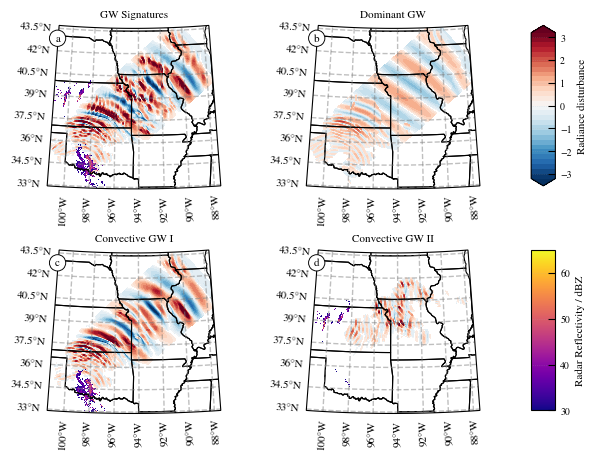

In [28]:
GW_1 = goliath[0]
GW_2 = david[0]

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
lon = ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))

lon_min = float(np.nanmin(lon)) + 1
lon_max = float(np.nanmax(lon)) - 1
lat_min = float(np.nanmin(lat)) + 0.5
lat_max = float(np.nanmax(lat)) - 0.5

clon = 0.5 * (lon_min + lon_max)
clat = 0.5 * (lat_min + lat_max)

projStr = ccrs.Stereographic(
    central_longitude=clon,
    central_latitude=clat
)

wave_lev = np.linspace(-3.2,3.2,31)

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(
    2, 3,
    hspace=0.4, wspace=0.1,
    width_ratios=[10, 10, 1],
    height_ratios=[1, 1]
)

# map axes
ax00 = fig.add_subplot(gs[0, 0], projection=projStr)
ax01 = fig.add_subplot(gs[0, 1], projection=projStr)
ax10 = fig.add_subplot(gs[1, 0], projection=projStr)
ax11 = fig.add_subplot(gs[1, 1], projection=projStr)

# colorbar axes (normal axes, no projection)
cax0 = fig.add_subplot(gs[0, 2])
cax1 = fig.add_subplot(gs[1, 2])

map_axes = [ax00, ax01, ax10, ax11]

xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = pt.nice_boundary_path_for_maps(xs, ys)

for a in map_axes:
    a.set_boundary(path, transform=ccrs.PlateCarree())
    a.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    a.coastlines(resolution='110m')
    a.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")

    gl = a.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.5,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = False

masked = np.ma.masked_inside(wavy_stuff, -0.2, 0.2)
plot_waves = ax00.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
cbar = fig.colorbar(plot_waves,cax=cax0,orientation='vertical',pad=0.05,label='Radiance disturbance',ticks=[-3, -2, -1, 0, 1, 2, 3])
ax00.set_title('GW Signatures')

masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax00.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax00.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
cbar = fig.colorbar(plot_KTLX,cax=cax1,orientation='vertical',pad=0.05,label='Radar Reflectivity / dBZ',ticks=[30,40,50,60])

masked = np.ma.masked_inside(recon_domi, -0.2, 0.2)  
plot_domi = ax01.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax01.set_title('Dominant GW')


masked = np.ma.masked_inside(GW_1, -0.2, 0.2)  
plot_GW1 = ax10.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
ax10.set_title('Convective GW I')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax10.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')


masked = np.ma.masked_inside(GW_2, -0.2, 0.2)  
plot_GW2 = ax11.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
ax11.set_title('Convective GW II')
masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax11.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')


label=['a','b','c','d']
for i,a in enumerate(map_axes):
    a.text(0.06,0.92,label[i],va='center', ha='center', bbox=letterbox, transform=a.transAxes)

plt.savefig('./figures/figure_3_v2.png', dpi=300, bbox_inches="tight",pad_inches=0.03)

In [20]:
kx_goliath, ky_goliath = AWE.rotate_wave_vector(goliath[2],goliath[3],ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353)).values,ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353)).values)
kx_david, ky_david     = AWE.rotate_wave_vector(david[2],david[3],ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353)).values,ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353)).values)
mask = ky_goliath<0
kx_goliath[mask]=-kx_goliath[mask]
ky_goliath[mask]=-ky_goliath[mask]
mask = ky_david<0
kx_david[mask]=-kx_david[mask]
ky_david[mask]=-ky_david[mask]

lh_goliath, th_goliath = two.kxky_2_lhtheta(kx_goliath,ky_goliath)
lh_david, th_david     = two.kxky_2_lhtheta(kx_david,ky_david)

/home/r/Robert.Reichert/WAVEGUISE/notebooks/../scripts/utils_2d_v3.py:949: RuntimeWarning: divide by zero encountered in divide
  return 2*np.pi/k, theta


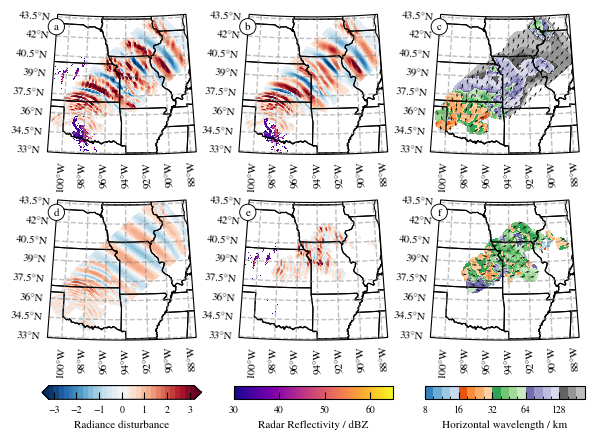

In [23]:
GW_1 = goliath[0]
GW_2 = david[0]

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
lon = ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))

lon_min = float(np.nanmin(lon)) + 1
lon_max = float(np.nanmax(lon)) - 1
lat_min = float(np.nanmin(lat)) + 0.5
lat_max = float(np.nanmax(lat)) - 0.5

clon = 0.5 * (lon_min + lon_max)
clat = 0.5 * (lat_min + lat_max)

projStr = ccrs.Stereographic(
    central_longitude=clon,
    central_latitude=clat
)

wave_lev = np.linspace(-3.2,3.2,31)

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(
    3, 3,
    hspace=0.5, wspace=0.2,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1, 0.1]
)

# map axes
ax00 = fig.add_subplot(gs[0, 0], projection=projStr)
ax01 = fig.add_subplot(gs[0, 1], projection=projStr)
ax02 = fig.add_subplot(gs[0, 2], projection=projStr)
ax10 = fig.add_subplot(gs[1, 0], projection=projStr)
ax11 = fig.add_subplot(gs[1, 1], projection=projStr)
ax12 = fig.add_subplot(gs[1, 2], projection=projStr)

# colorbar axes (normal axes, no projection)
cax0 = fig.add_subplot(gs[2, 0])
cax1 = fig.add_subplot(gs[2, 1])
cax2 = fig.add_subplot(gs[2, 2])

map_axes = [ax00, ax01, ax02, ax10, ax11, ax12]

xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = pt.nice_boundary_path_for_maps(xs, ys)

for a in map_axes:
    a.set_boundary(path, transform=ccrs.PlateCarree())
    a.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    a.coastlines(resolution='110m')
    a.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")

    gl = a.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.5,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = False

masked = np.ma.masked_inside(wavy_stuff, -0.2, 0.2)
plot_waves = ax00.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
cbar = fig.colorbar(plot_waves,cax=cax0,orientation='horizontal',pad=0.05,label='Radiance disturbance',ticks=[-3, -2, -1, 0, 1, 2, 3])
#ax00.set_title('GW Signatures')

masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax00.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax00.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
cbar = fig.colorbar(plot_KTLX,cax=cax1,orientation='horizontal',pad=0.05,label='Radar Reflectivity / dBZ',ticks=[30,40,50,60])

masked = np.ma.masked_inside(recon_domi, -0.2, 0.2)  
plot_domi = ax10.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
#ax10.set_title('Dominant GW')


masked = np.ma.masked_inside(GW_1, -0.2, 0.2)  
plot_GW1 = ax01.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
#ax11.set_title('Convective GW I')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax01.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')


masked = np.ma.masked_inside(GW_2, -0.2, 0.2)  
plot_GW2 = ax11.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
#ax01.set_title('Convective GW II')
masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax11.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')


# 19 Intervalle -> 19 Farben nehmen
lh_lev = cwt_result['period'][::2]*1e-3
base = plt.get_cmap("tab20c")
colors = base(np.linspace(0, 1, len(lh_lev) - 1))
cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(lh_lev, cmap.N)

steps = 30

# GOLIATH
field = lh_goliath * 1e-3
mask  = goliath[1] > 0
field_masked = np.ma.masked_where(~mask, field)

plot_WP = ax02.contourf(lon, lat, field_masked, levels=lh_lev, cmap='tab20c', norm=norm, transform=ccrs.PlateCarree())

lon_q = ds['Longitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values
lat_q = ds['Latitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values

u = np.cos(th_goliath)
v = np.sin(th_goliath)

u = np.ma.masked_where(~mask, u)
v = np.ma.masked_where(~mask, v)
lon_q = np.ma.masked_where(~mask, lon_q)
lat_q = np.ma.masked_where(~mask, lat_q)

ax02.quiver(lon_q[::steps, ::steps], lat_q[::steps, ::steps], u[::steps, ::steps], v[::steps, ::steps], scale=30, transform=ccrs.PlateCarree())


# DAVID
field = lh_david * 1e-3
mask  = david[1] > 0
field_masked = np.ma.masked_where(~mask, field)

plot_WP = ax12.contourf(lon, lat, field_masked, levels=lh_lev, cmap='tab20c', norm=norm, transform=ccrs.PlateCarree())

lon_q = ds['Longitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values
lat_q = ds['Latitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values

u = np.cos(th_david)
v = np.sin(th_david)

u = np.ma.masked_where(~mask, u)
v = np.ma.masked_where(~mask, v)
lon_q = np.ma.masked_where(~mask, lon_q)
lat_q = np.ma.masked_where(~mask, lat_q)

ax12.quiver(lon_q[::steps, ::steps], lat_q[::steps, ::steps], u[::steps, ::steps], v[::steps, ::steps], scale=30, transform=ccrs.PlateCarree())

cbar = fig.colorbar(plot_WP,cax=cax2,orientation='horizontal',pad=0.05,label='Horizontal wavelength / km',ticks=[8,16,32,64,128,256],spacing='uniform')


label=['a','b','c','d','e','f']
for i,a in enumerate(map_axes):
    a.text(0.06,0.91,label[i],va='center', ha='center', bbox=letterbox, transform=a.transAxes)

plt.savefig('./figures/figure_3_v3.png', dpi=300, bbox_inches="tight",pad_inches=0.03)

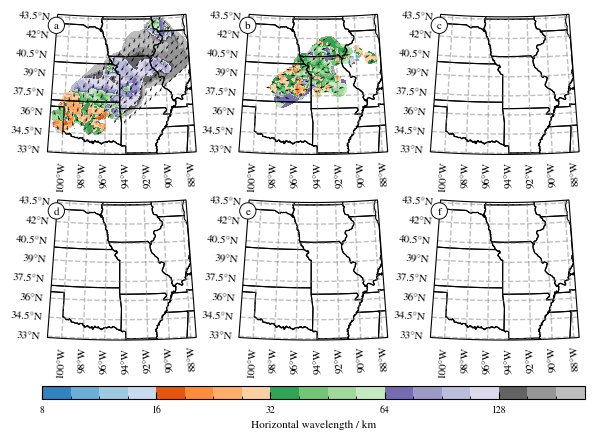

In [38]:
import matplotlib as mpl

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
lon = ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))

lon_min = float(np.nanmin(lon)) + 1
lon_max = float(np.nanmax(lon)) - 1
lat_min = float(np.nanmin(lat)) + 0.5
lat_max = float(np.nanmax(lat)) - 0.5

clon = 0.5 * (lon_min + lon_max)
clat = 0.5 * (lat_min + lat_max)

projStr = ccrs.Stereographic(
    central_longitude=clon,
    central_latitude=clat
)

lh_lev = cwt_result['period'][::2]*1e-3

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(
    3, 3,
    hspace=0.5, wspace=0.2,
    width_ratios=[1, 1, 1],
    height_ratios=[10, 10, 1]
)

# map axes
ax00 = fig.add_subplot(gs[0, 0], projection=projStr)
ax01 = fig.add_subplot(gs[0, 1], projection=projStr)
ax02 = fig.add_subplot(gs[0, 2], projection=projStr)
ax10 = fig.add_subplot(gs[1, 0], projection=projStr)
ax11 = fig.add_subplot(gs[1, 1], projection=projStr)
ax12 = fig.add_subplot(gs[1, 2], projection=projStr)

# colorbar axes (normal axes, no projection)
cax = fig.add_subplot(gs[2, :])
#cax1 = fig.add_subplot(gs[2, 1])

map_axes = [ax00, ax01, ax02, ax10, ax11, ax12]

xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = pt.nice_boundary_path_for_maps(xs, ys)

for a in map_axes:
    a.set_boundary(path, transform=ccrs.PlateCarree())
    a.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    a.coastlines(resolution='110m')
    a.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")

    gl = a.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.5,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = False

# 19 Intervalle -> 19 Farben nehmen
base = plt.get_cmap("tab20c")
colors = base(np.linspace(0, 1, len(lh_lev) - 1))
cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(lh_lev, cmap.N)

steps = 30

# GOLIATH
field = lh_goliath * 1e-3
mask  = goliath[1] > 0
field_masked = np.ma.masked_where(~mask, field)

plot_WP = map_axes[0].contourf(lon, lat, field_masked, levels=lh_lev, cmap='tab20c', norm=norm, transform=ccrs.PlateCarree())

lon_q = ds['Longitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values
lat_q = ds['Latitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values

u = np.cos(th_goliath)
v = np.sin(th_goliath)

u = np.ma.masked_where(~mask, u)
v = np.ma.masked_where(~mask, v)
lon_q = np.ma.masked_where(~mask, lon_q)
lat_q = np.ma.masked_where(~mask, lat_q)

map_axes[0].quiver(lon_q[::steps, ::steps], lat_q[::steps, ::steps], u[::steps, ::steps], v[::steps, ::steps], scale=30, transform=ccrs.PlateCarree())


# DAVID
field = lh_david * 1e-3
mask  = david[1] > 0
field_masked = np.ma.masked_where(~mask, field)

plot_WP = map_axes[1].contourf(lon, lat, field_masked, levels=lh_lev, cmap='tab20c', norm=norm, transform=ccrs.PlateCarree())

lon_q = ds['Longitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values
lat_q = ds['Latitude'].isel(time=0, x_along_track=slice(5100,5800), y_cross_track=slice(85,353)).values

u = np.cos(th_david)
v = np.sin(th_david)

u = np.ma.masked_where(~mask, u)
v = np.ma.masked_where(~mask, v)
lon_q = np.ma.masked_where(~mask, lon_q)
lat_q = np.ma.masked_where(~mask, lat_q)

map_axes[1].quiver(lon_q[::steps, ::steps], lat_q[::steps, ::steps], u[::steps, ::steps], v[::steps, ::steps], scale=30, transform=ccrs.PlateCarree())

cbar = fig.colorbar(plot_WP,cax=cax,orientation='horizontal',pad=0.05,label='Horizontal wavelength / km',ticks=[8,16,32,64,128,256],spacing='uniform')

label=['a','b','c','d','e','f']
for i,a in enumerate(map_axes):
    a.text(0.06,0.92,label[i],va='center', ha='center', bbox=letterbox, transform=a.transAxes)

#Titel='Orbit 02514'
#plt.savefig('./figures/2D_AWE_WP_overview.png', dpi=300, bbox_inches="tight",pad_inches=0.03)

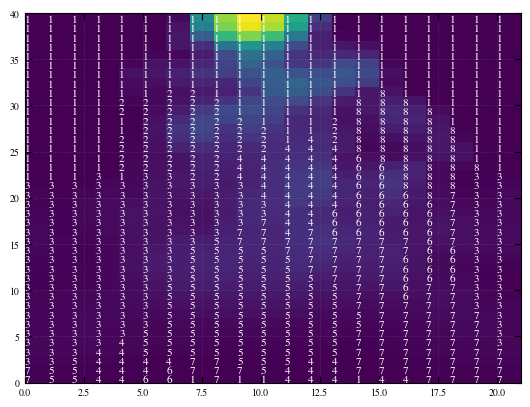

In [68]:
bin_ranges = [0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5]
plt.pcolormesh(np.mean(WAS,axis=(2,3)))#,levels=np.linspace(0,0.4,31),extend='both')
for i in range(WAS.shape[0]):
    for j in range(WAS.shape[1]):
        counts, bins = np.histogram(seg_v3[i,j,:,:],bins=bin_ranges)
        
        plt.text(j,i,np.argmax(counts)+1,horizontalalignment='left',c='white')

suggested scaling: 0.579168450400712
[-1  0  1  2  3  4  5  6  7  8  9 10]


Text(0.5, 1.0, 'Clustered Wave Packets')

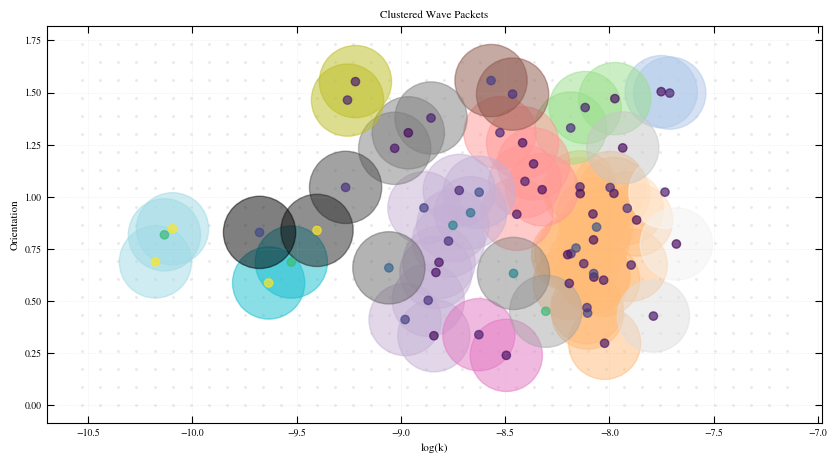

In [105]:
ds = np.abs(np.diff(np.log(k))[0])
dt = np.diff(orientation)[0]
print('suggested scaling:', ds/dt)
scaling=ds/dt

fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot()

# Grid
for ia in k:
    for ib in orientation:
        ax.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)

# Clusters
unique_clusters = np.unique(cluster_labels)
print(unique_clusters)
colors = cm.get_cmap('tab20', len(unique_clusters))

for idx, cid in enumerate(unique_clusters):
    if cid == -1:
        continue
    mask = cluster_labels == cid
    if np.sum(mask) > 1:
        xs = np.log(k_seg_3[mask])
        ys = scaling*theta_seg_3[mask]
        color = colors(idx / (len(unique_clusters) - 1))
        for xx, yy in zip(xs, ys):
            circle = plt.Circle((xx, yy), eps, alpha=0.5, color=color)
            ax.add_patch(circle)

noise_indices = np.where(cluster_labels == -1)[0]
n_noise = len(noise_indices)

for j, i in enumerate(noise_indices):
    xx = np.log(k_seg_3[i])
    yy = scaling * theta_seg_3[i]
    color = cm.Greys(j / max(n_noise - 1, 1))
    circle = plt.Circle((xx, yy), eps, alpha=0.5, color=color)
    ax.add_patch(circle)

# ALL initial wavepackets
vmax = np.percentile(amp_seg_3,95)
ax.scatter(np.log(k_seg_3),scaling*theta_seg_3,c=amp_seg_3,alpha=0.67,vmin=0,vmax=vmax)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel('log(k)')
ax.set_ylabel('Orientation')
ax.set_title('Clustered Wave Packets')

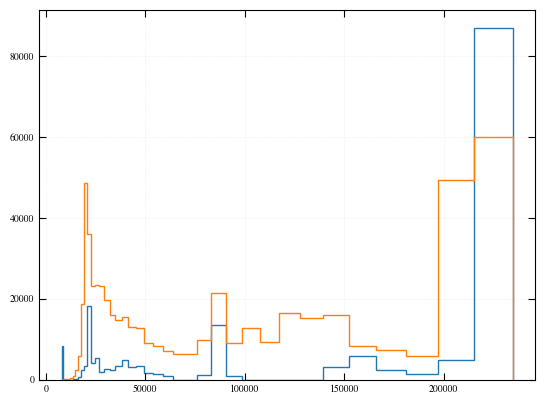

In [90]:
mask = amp_seg_v3 > 0
counts_domi, bins = np.histogram(domi['period'],bins=cwt_copy['period'])
counts_seg, bins = np.histogram(lh_seg_v3[mask],bins=cwt_copy['period'])
plt.stairs(counts_domi, bins)
plt.stairs(counts_seg, bins)

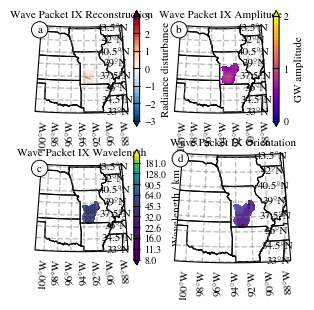

In [95]:
lon = ds['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lonW, lonE = lon.min(), lon.max()
latN, latS = lat.max(), lat.min()
clon, clat = (lonW+lonE)/2, (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon.values, central_latitude=clat.values)
wave_lev = np.linspace(-3,3,31)
amp_lev = np.linspace(0,2,31)
lh_lev = cwt_copy['period']
th_lev = cwt_copy['theta']

idx = 8

fig=plt.figure(figsize=(3.3,3.3))

ax1 = fig.add_subplot(221,projection=projStr)
masked = np.ma.masked_inside(recon_seg_v3[idx,:,:], -0.2, 0.2)  
plot_wave = plot_AWE(lon, lat, masked, wave_lev, 'RdBu_r', ax1)
cbar = fig.colorbar(plot_wave,label='Radiance disturbance',ticks=[-3,-2,-1,0,1,2,3])
ax1.set_title('Wave Packet IX Reconstruction')

ax2 = fig.add_subplot(222,projection=projStr)
amp_data = np.where(amp_seg_v3[idx,:,:] == 0, np.nan, amp_seg_v3[idx,:,:])
plot_amp = plot_AWE(lon, lat, amp_data, amp_lev, 'plasma', ax2)
cbar = fig.colorbar(plot_amp,label='GW amplitude',ticks=[0,1,2])
ax2.set_title('Wave Packet IX Amplitude')

ax3 = fig.add_subplot(223,projection=projStr) 
lh_data = np.where(amp_seg_v3[idx,:,:] == 0, np.nan, lh_seg_v3[idx,:,:])
plot_lh=plot_AWE(lon, lat, lh_data*1e-3, lh_lev*1e-3, 'viridis', ax3)
cbar = fig.colorbar(plot_lh,label='Wavelength / km')
ax3.set_title('Wave Packet IX Wavelength')

ax4 = fig.add_subplot(224,projection=projStr)
th_data = np.where(amp_seg_v3[idx,:,:] == 0, np.nan, th_seg_v3[idx,:,:])
plot_AWE(lon, lat, th_data, th_lev, 'twilight', ax4)
ax3.quiver(lon.values[::20,::20], lat.values[::20,::20], np.cos(th_data[::20,::20]), np.sin(th_data[::20,::20]),scale=30,transform=ccrs.PlateCarree())
ax4.set_title('Wave Packet IX Orientation')

axes=[ax1,ax2,ax3,ax4]
label=['a','b','c','d']
for i,a in enumerate(axes):
    a.text(0.05,0.95,label[i],va='center', ha='center', bbox=letterbox, transform=a.transAxes)

#Titel='Orbit 02514'
plt.savefig('./figures/WAVEGUISE_WP_IX.png', dpi=300, bbox_inches="tight",pad_inches=0.03)

185397
527538


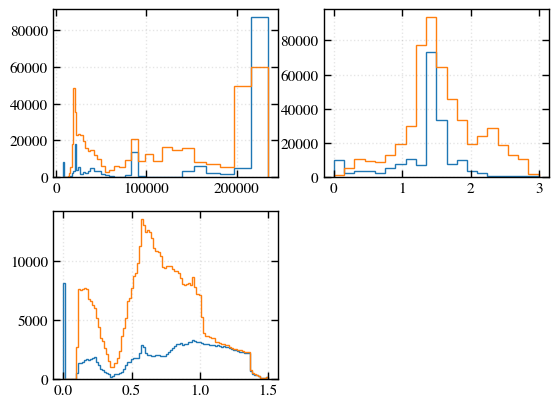

In [82]:
mask = amp_seg_v3 > 0

fig = plt.figure()

ax1 = fig.add_subplot(221)
counts, bins = np.histogram(domi['period'],bins=cwt_copy['period'])
ax1.stairs(counts, bins)
counts, bins = np.histogram(lh_seg_v3[mask],bins=cwt_copy['period'])
ax1.stairs(counts, bins)

ax2 = fig.add_subplot(222)
counts, bins = np.histogram(domi['theta'],bins=cwt_copy['theta'])
ax2.stairs(counts, bins)
counts, bins = np.histogram(th_seg_v3[mask],bins=cwt_copy['theta'])
ax2.stairs(counts, bins)

ax3 = fig.add_subplot(223)
counts, bins = np.histogram(domi['coefficient'],bins=100,range=[0,1.5])
ax3.stairs(counts, bins)
print(np.sum(counts))
counts, bins = np.histogram(amp_seg_v3[mask],bins=100,range=[0,1.5])
ax3.stairs(counts, bins)
print(np.sum(counts))

In [ ]:
titlebox = {"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}

rad_lev   = np.linspace(-7,7,31)
lev_ticks = [-7,-5,-3,-1,1,3,5,7]

fig=plt.figure(figsize=(nx/25,ny/25))
ax=fig.add_subplot(221)
ax.contourf(x,y,orig,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Original BI Measurement')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")

ax=fig.add_subplot(222)
plot_BG = ax.contourf(x,y,BI_low+noisy_stuff,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Background + Noise')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
cbar = fig.colorbar(plot_BG,label="Band Intensity",ticks=lev_ticks)
ax.text(0.12,0.95, f"$\sigma_{{noise}} = {np.std(noisy_stuff):.2f}$", verticalalignment='center', horizontalalignment='center', weight = 'bold', bbox=titlebox, transform=ax.transAxes)

ax=fig.add_subplot(223)
masked = np.ma.masked_inside(wavy_stuff, -0.2, 0.2)  
norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
ax.contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
ax.set_title('Wavy Stuff')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
ax.grid(which='both')

#plt.savefig('./AWE_plots/AWE_preparation_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-12941388/ipykernel_143/1754042510.py:16: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Orientation / $\circ$')


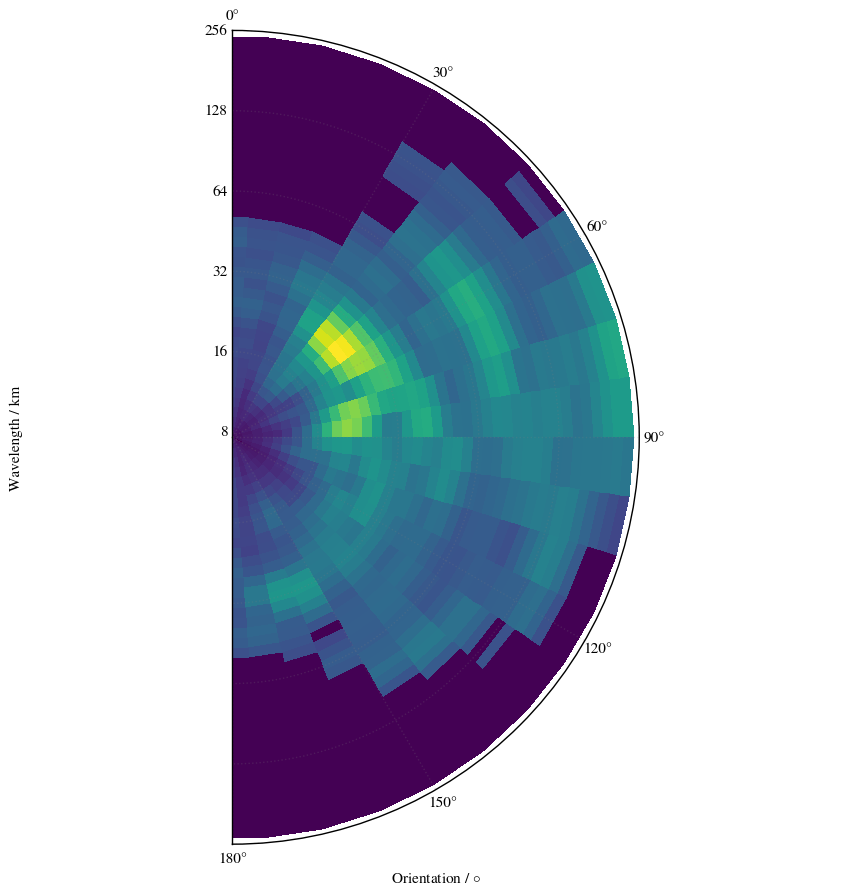

In [11]:
#WPS[WPS==0]=np.nan
sel_WPS = np.nanmax(WPS,axis=(2,3))
#spec_lev = pc.cmap_range(sel_WPS, [1,99], diverging=False, fix_zero=True, num_levels=31)
sel_WPS_pad = np.pad(sel_WPS, ((0,0),(0,sel_WPS.shape[1])), mode="wrap")

fig = plt.figure(figsize=(0.5*len(result['theta']),0.5*len(result['scale'])))
ax=fig.add_subplot(projection='polar')

pcm = ax.pcolormesh(th2,pe*1e-3,sel_WPS_pad, shading="auto")#vmin=spec_lev.min(), vmax=spec_lev.max(),)
ax.set_yscale('log')
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)
ax.set_xlim([0,np.pi])

ax.set_ylabel('Wavelength / km')
ax.set_xlabel('Orientation / $\circ$')
ax.set_yticks(ticks=[8,16,32,64,128,256],labels=[8,16,32,64,128,256])

#plt.savefig('./AWE_plots/mean_spectrum_02514.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-12049865/ipykernel_354/1021758661.py:21: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Orientation / $\circ$')


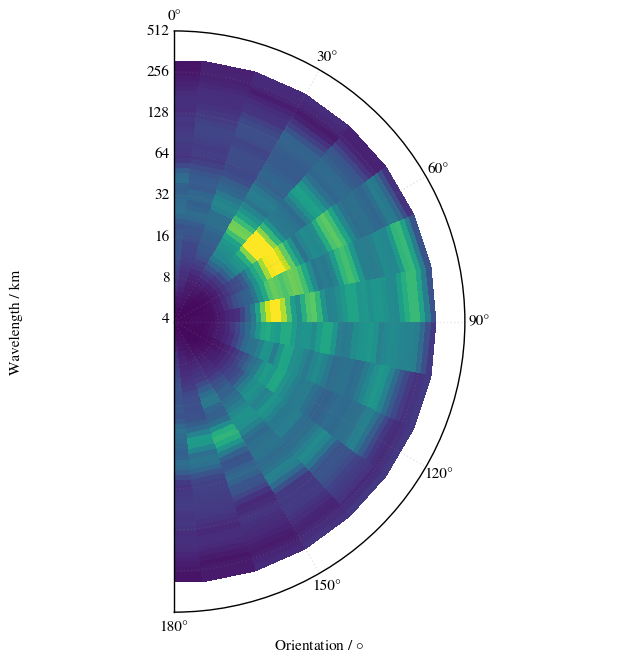

In [12]:
WPS = np.abs(result['decomposition'])

th=result['theta']
th2 = np.append(th,th+np.pi)
pe=result['period']

sel_WPS = np.max(WPS,axis=(2,3))
spec_lev = pc.cmap_range(sel_WPS, [1,99], diverging=False, fix_zero=True, num_levels=31)
sel_WPS_pad = np.pad(sel_WPS, ((0,0),(0,sel_WPS.shape[1])), mode="wrap")

fig = plt.figure(figsize=(0.5*len(result['theta']),0.5*len(result['scale'])))
ax=fig.add_subplot(projection='polar')

pcm = ax.pcolormesh(th2,pe*1e-3,sel_WPS_pad,vmin=spec_lev.min(), vmax=spec_lev.max(), shading="auto")
ax.set_yscale('log')
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)
ax.set_xlim([0,np.pi])

ax.set_ylabel('Wavelength / km')
ax.set_xlabel('Orientation / $\circ$')
ax.set_yticks(ticks=[4,8,16,32,64,128,256,512],labels=[4,8,16,32,64,128,256,512])

#plt.savefig('./AWE_plots/mean_spectrum_02514.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

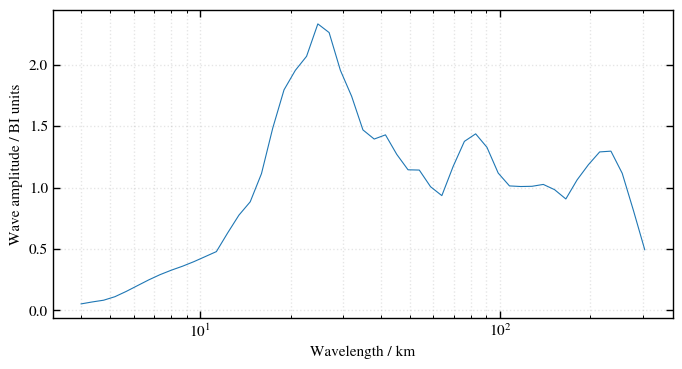

In [13]:
pe=result['period']
sel_WPS = np.max(WPS,axis=(1,2,3))

fig = plt.figure(figsize=(8,4))

plt.plot(pe*1e-3,sel_WPS)
plt.xlabel('Wavelength / km')
plt.ylabel('Wave amplitude / BI units')
plt.xscale("log")
plt.grid(which="both")

#plt.savefig('./AWE_plots/wavelength_spectrum_02514.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")